In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os
from tqdm import tqdm

zip_path = '/content/drive/MyDrive/Colab Notebooks/brain tumor/Brain Tumor Dataset.zip'
extract_to = '/content/tumor_dataset'

# Extract file-by-file (prevents memory crashes)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    all_files = zip_ref.namelist()
    for file in tqdm(all_files, desc=" Extracting ZIP"):
        zip_ref.extract(file, extract_to)

print(" Done Extracting ZIP!")

 Extracting ZIP: 100%|██████████| 7034/7034 [00:05<00:00, 1233.84it/s]

 Done Extracting ZIP!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import itertools



In [5]:
# ================================
# 1. Load Dataset
# ================================
train_dir = '/content/tumor_dataset/Brain Tumor Dataset/Training'
test_dir = '/content/tumor_dataset/Brain Tumor Dataset/Testing'

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 20% for validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)



Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


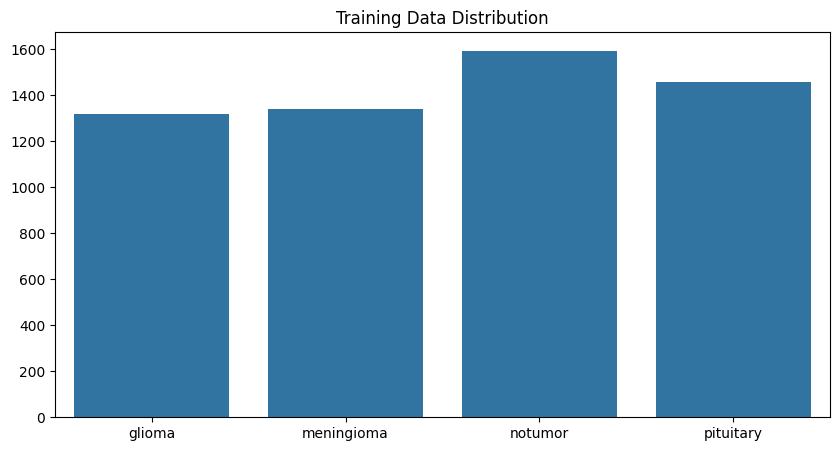

In [6]:
# ================================
# 2. EDA
# ================================

# Class Distribution
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
test_counts = {cls: len(os.listdir(os.path.join(test_dir, cls))) for cls in class_names}

plt.figure(figsize=(10,5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Training Data Distribution")
plt.show()



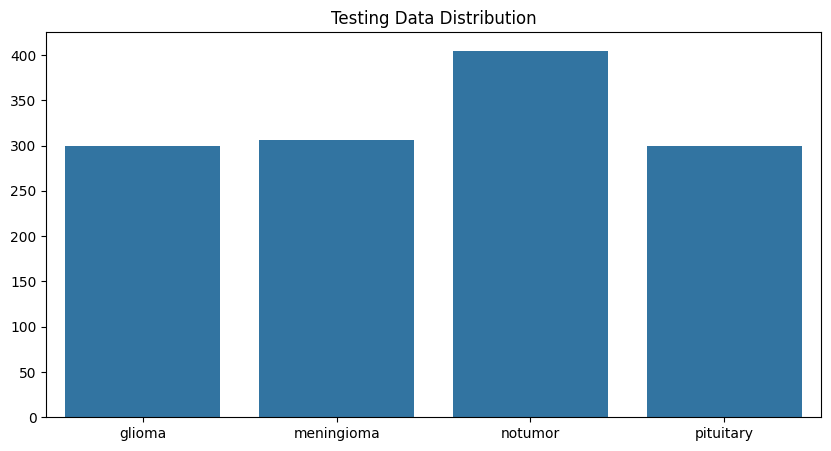

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()))
plt.title("Testing Data Distribution")
plt.show()



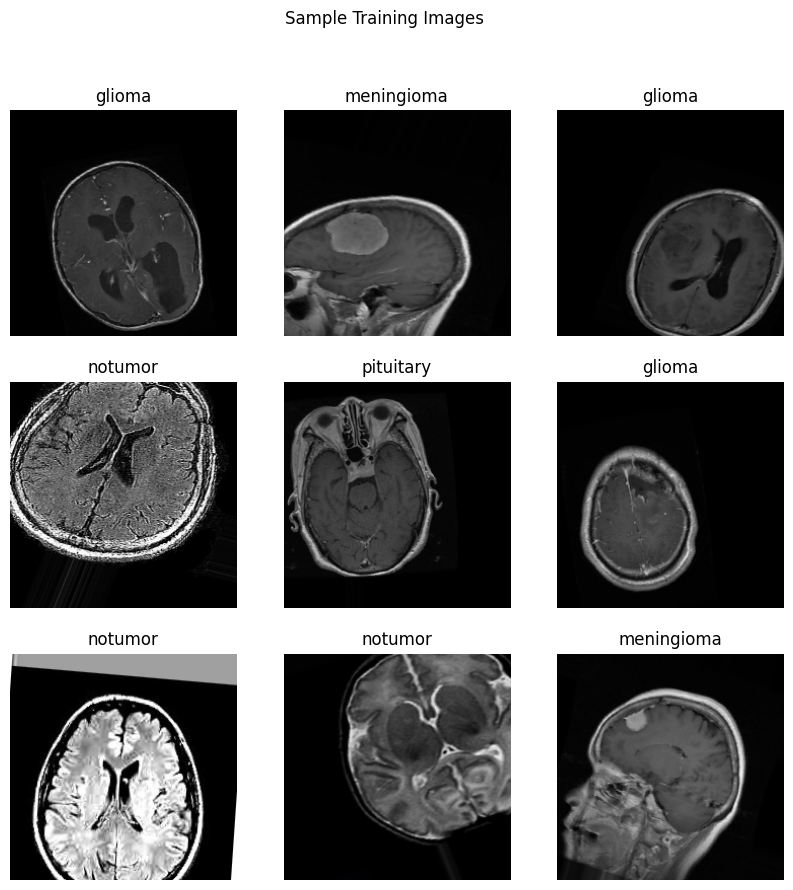

In [7]:
# Show sample images
x, y = next(iter(train_generator))
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x[i])
    plt.title(class_names[np.argmax(y[i])])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()



In [12]:
# ================================
# 3. Build ResNet50 Model for fine-tuning
# ================================
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))

# Unfreeze some layers of the base model for fine-tuning
for layer in base_model.layers[-30:]: # Unfreeze the last 30 layers
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x) # Increased units
x = Dropout(0.5)(x) # Increased dropout
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Experiment with hyperparameters: Learning rate and optimizer
learning_rate = 1e-5 # You can change this value
optimizer = Adam(learning_rate=learning_rate) # You can try other optimizers like SGD

model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

In [13]:
# ================================
# 4. Train Model
# ================================
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)



Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 181s 854ms/step - accuracy: 0.3408 - loss: 1.6495 - val_accuracy: 0.2340 - val_loss: 1.3973
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 620ms/step - accuracy: 0.6069 - loss: 0.9305 - val_accuracy: 0.3015 - val_loss: 1.3464
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 88s 613ms/step - accuracy: 0.7896 - loss: 0.5996 - val_accuracy: 0.3918 - val_loss: 1.3645
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 628ms/step - accuracy: 0.8529 - loss: 0.4298 - val_accuracy: 0.3769 - val_loss: 1.3356
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 141s 624ms/step - accuracy: 0.8900 - loss: 0.3480 - val_accuracy: 0.4435 - val_loss: 1.2818
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 626ms/step - accuracy: 0.9115 - loss: 0.2816 - val_accuracy: 0.4978 - val_loss: 1.2072
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 145s 646ms/step - accuracy: 0.9165 - loss: 0.2577 - val_accuracy: 0.6486 - val_loss: 0.8804
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 87s 607ms/step - accuracy: 0.9331 - loss

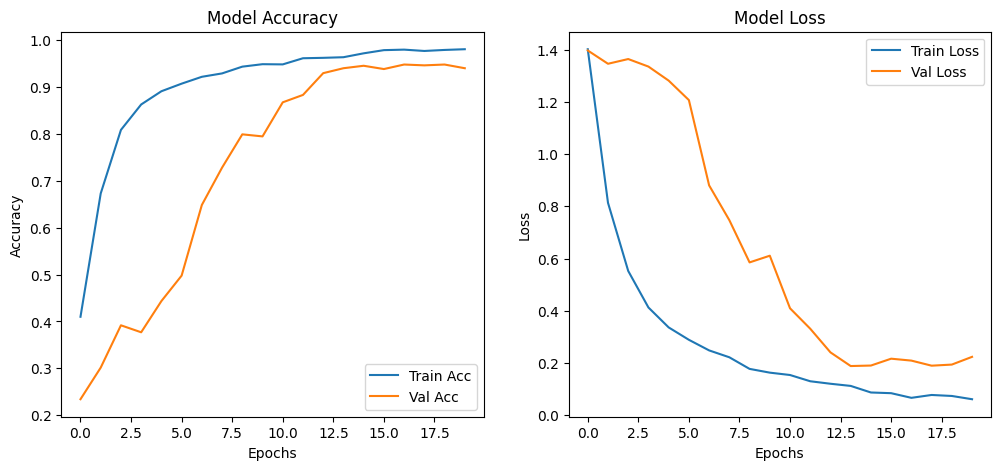

In [14]:
# ================================
# 5. Evolution Plots
# ================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()



In [16]:
# ================================
# 6. Evaluation on Test Set
# ================================
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print("\nClassification Report:\n", classification_report(y_true, y_pred_classes, target_names=class_names))



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step

Classification Report:
               precision    recall  f1-score   support

      glioma       0.95      0.98      0.96       300
  meningioma       0.99      0.89      0.93       306
     notumor       0.98      0.97      0.98       405
   pituitary       0.92      1.00      0.96       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



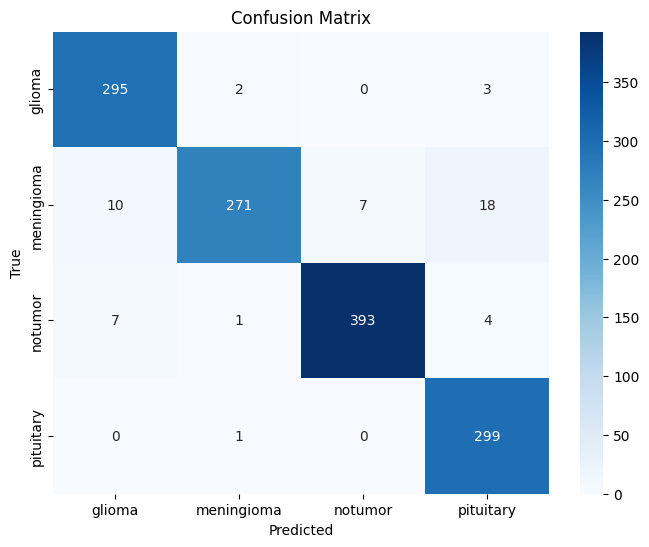

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



In [15]:
# ================================
# 7. Save Model
# ================================
model.save("brain_tumor_resnet50.h5")
print("Model saved as brain_tumor_resnet50.h5")


Model saved as brain_tumor_resnet50.h5
